Copyright 2025 © Amazon.com and Affiliates: This deliverable is considered Developed Content as defined in the AWS Service Terms.

In [31]:
import os
import pandas as pd

draw_quantize_plot = False
target_folders = [
    "/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/gpu_bf16_tp2_best",
    "/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/gpu_bf16_tp4_best",
    # "/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/inf2_bf16_tp4_best",
    "/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/inf2_bf16_tp8_best",
    # "/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/inf2_bf16_tp16_best",
    # "/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/trn2_bf16_tp16_best"
    "/home/ubuntu/daanggn-neuron-inference-migration/e2e_pipeline/results/inf2_bf16_tp8_v27",
    "/home/ubuntu/daanggn-neuron-inference-migration/e2e_pipeline/results/inf2_bf16_tp82_v27",

]

# draw_quantize_plot = True
# target_folders = [
#     "/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/gpu_bf16_tp2_best",
#     "/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/gpu_fp8_tp2_best",
#     "/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/inf2_bf16_tp8_best",
#     "/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/inf2_fp8_tp8_best"
# ]

combined_dfs = []
for folder in target_folders:
    for file in os.listdir(folder):
        if file.endswith('.json'):
            df = pd.read_json(os.path.join(folder, file))
            
            df['instance_type'] = 'A100' if 'gpu' in folder.lower() else folder.split("/")[-1].split("_")[0].upper()
            df['tp_degree'] = int(folder.split('tp')[1].split('_')[0]) if 'tp' in folder else None
            df['quantized'] = 'bf16' if 'bf16' in folder.lower() else 'fp8'
            if draw_quantize_plot:
                df['identifier'] = f"{df['instance_type'][0]}_tp{df['tp_degree'][0]}_{df['quantized'][0]}"
            else:
                df['identifier'] = f"{df['instance_type'][0]}_tp{df['tp_degree'][0]}"
                
            if folder.endswith('v27'):
                df['identifier'] = f"{df['instance_type'][0]}_tp{df['tp_degree'][0]}_v27"

            df = df[[
            'identifier', 'instance_type', 'tp_degree', 'quantized', 'max_concurrency',
            'request_throughput', 'total_token_throughput', 
            'mean_ttft_ms', 'median_ttft_ms', 'p99_ttft_ms', 
            'mean_tpot_ms', 'median_tpot_ms', 'p99_tpot_ms', 
            'mean_itl_ms', 'median_itl_ms', 'p99_itl_ms', 
            'mean_e2el_ms', 'median_e2el_ms', 'p99_e2el_ms',
            'completed', 'failed'
            ]].drop_duplicates()
            
            # Calculate cost
            gpu_hourly_cost = 21.957642 
            inf2_48x_hourly_cost = 12.98127
            inf2_24x_hourly_cost = 6.49063
            trn2_48x_hourly_cost = 35.7608

            def calculate_cost(row):
                if row['instance_type'] == 'A100':
                    return (gpu_hourly_cost * (row['tp_degree'] / 8)) / (3600 * row['total_token_throughput']) * 1000
                elif row['instance_type'] == 'INF2':
                    if row['tp_degree'] == 4:
                        return (inf2_24x_hourly_cost * (row['tp_degree'] / 12)) / (3600 * row['total_token_throughput']) * 1000
                    return (inf2_48x_hourly_cost * (row['tp_degree'] / 24)) / (3600 * row['total_token_throughput']) * 1000
                elif row['instance_type'] == 'TRN2':
                    return (trn2_48x_hourly_cost * (row['tp_degree'] / 64)) / (3600 * row['total_token_throughput']) * 1000
                else:
                    return None

            df['cost'] = df.apply(calculate_cost, axis=1)
            
            combined_dfs.append(df)

combined_df = pd.concat(combined_dfs, ignore_index=True)
combined_df


,identifier,instance_type,tp_degree,quantized,max_concurrency,request_throughput,total_token_throughput,mean_ttft_ms,median_ttft_ms,p99_ttft_ms,...,p99_tpot_ms,mean_itl_ms,median_itl_ms,p99_itl_ms,mean_e2el_ms,median_e2el_ms,p99_e2el_ms,completed,failed,cost
0,A100_tp2,A100,2,bf16,2,0.395224,77.833475,133.107183,143.308861,183.549703,...,27.421082,26.885720,26.672166,29.740538,5045.541594,5160.773312,7529.226685,200,0,0.019591
1,A100_tp2,A100,2,bf16,1,0.196509,39.176070,143.092121,143.438899,148.663476,...,26.909228,26.684466,26.820410,27.237301,5088.534814,5114.176390,7542.740649,100,0,0.038923
2,A100_tp2,A100,2,bf16,16,2.441690,476.178415,166.030250,126.055214,1331.611470,...,36.918095,34.860233,29.748519,93.849247,6467.930679,6594.604843,9772.058523,500,0,0.003202
3,A100_tp2,A100,2,bf16,8,1.411806,275.494092,141.075903,123.403601,671.324526,...,31.716569,30.296480,27.942486,91.041116,5622.323527,5762.054689,8453.720745,500,0,0.005535
4,A100_tp2,A100,2,bf16,4,0.761908,149.455792,138.724893,144.818605,283.098151,...,28.925350,27.927920,27.032766,87.122205,5218.894239,5343.723780,7885.669490,400,0,0.010203
5,A100_tp4,A100,4,bf16,4,1.141325,223.691067,133.330164,128.134590,221.030371,...,19.306394,18.525061,17.560039,72.129082,3485.356617,3569.637727,5245.661931,400,0,0.013633
6,A100_tp4,A100,4,bf16,8,2.096217,408.795925,133.716690,114.337670,646.238857,...,21.267539,20.283208,18.079483,73.588075,3784.174197,3882.060223,5681.800205,500,0,0.007460
7,A100_tp4,A100,4,bf16,1,0.295509,58.540414,128.865906,128.435245,141.281198,...,17.935261,17.682371,17.774582,18.228826,3383.672077,3417.626243,5031.567569,100,0,0.052095
8,A100_tp4,A100,4,bf16,2,0.592405,116.369125,139.136704,144.398922,189.113663,...,18.208362,17.780886,17.484580,34.011166,3366.910214,3411.951259,5051.047348,200,0,0.026207
9,A100_tp4,A100,4,bf16,16,3.540297,688.750557,149.898875,117.055671,1098.592516,...,25.862681,23.928321,19.546847,77.003473,4459.875404,4548.872383,6738.960142,500,0,0.004428


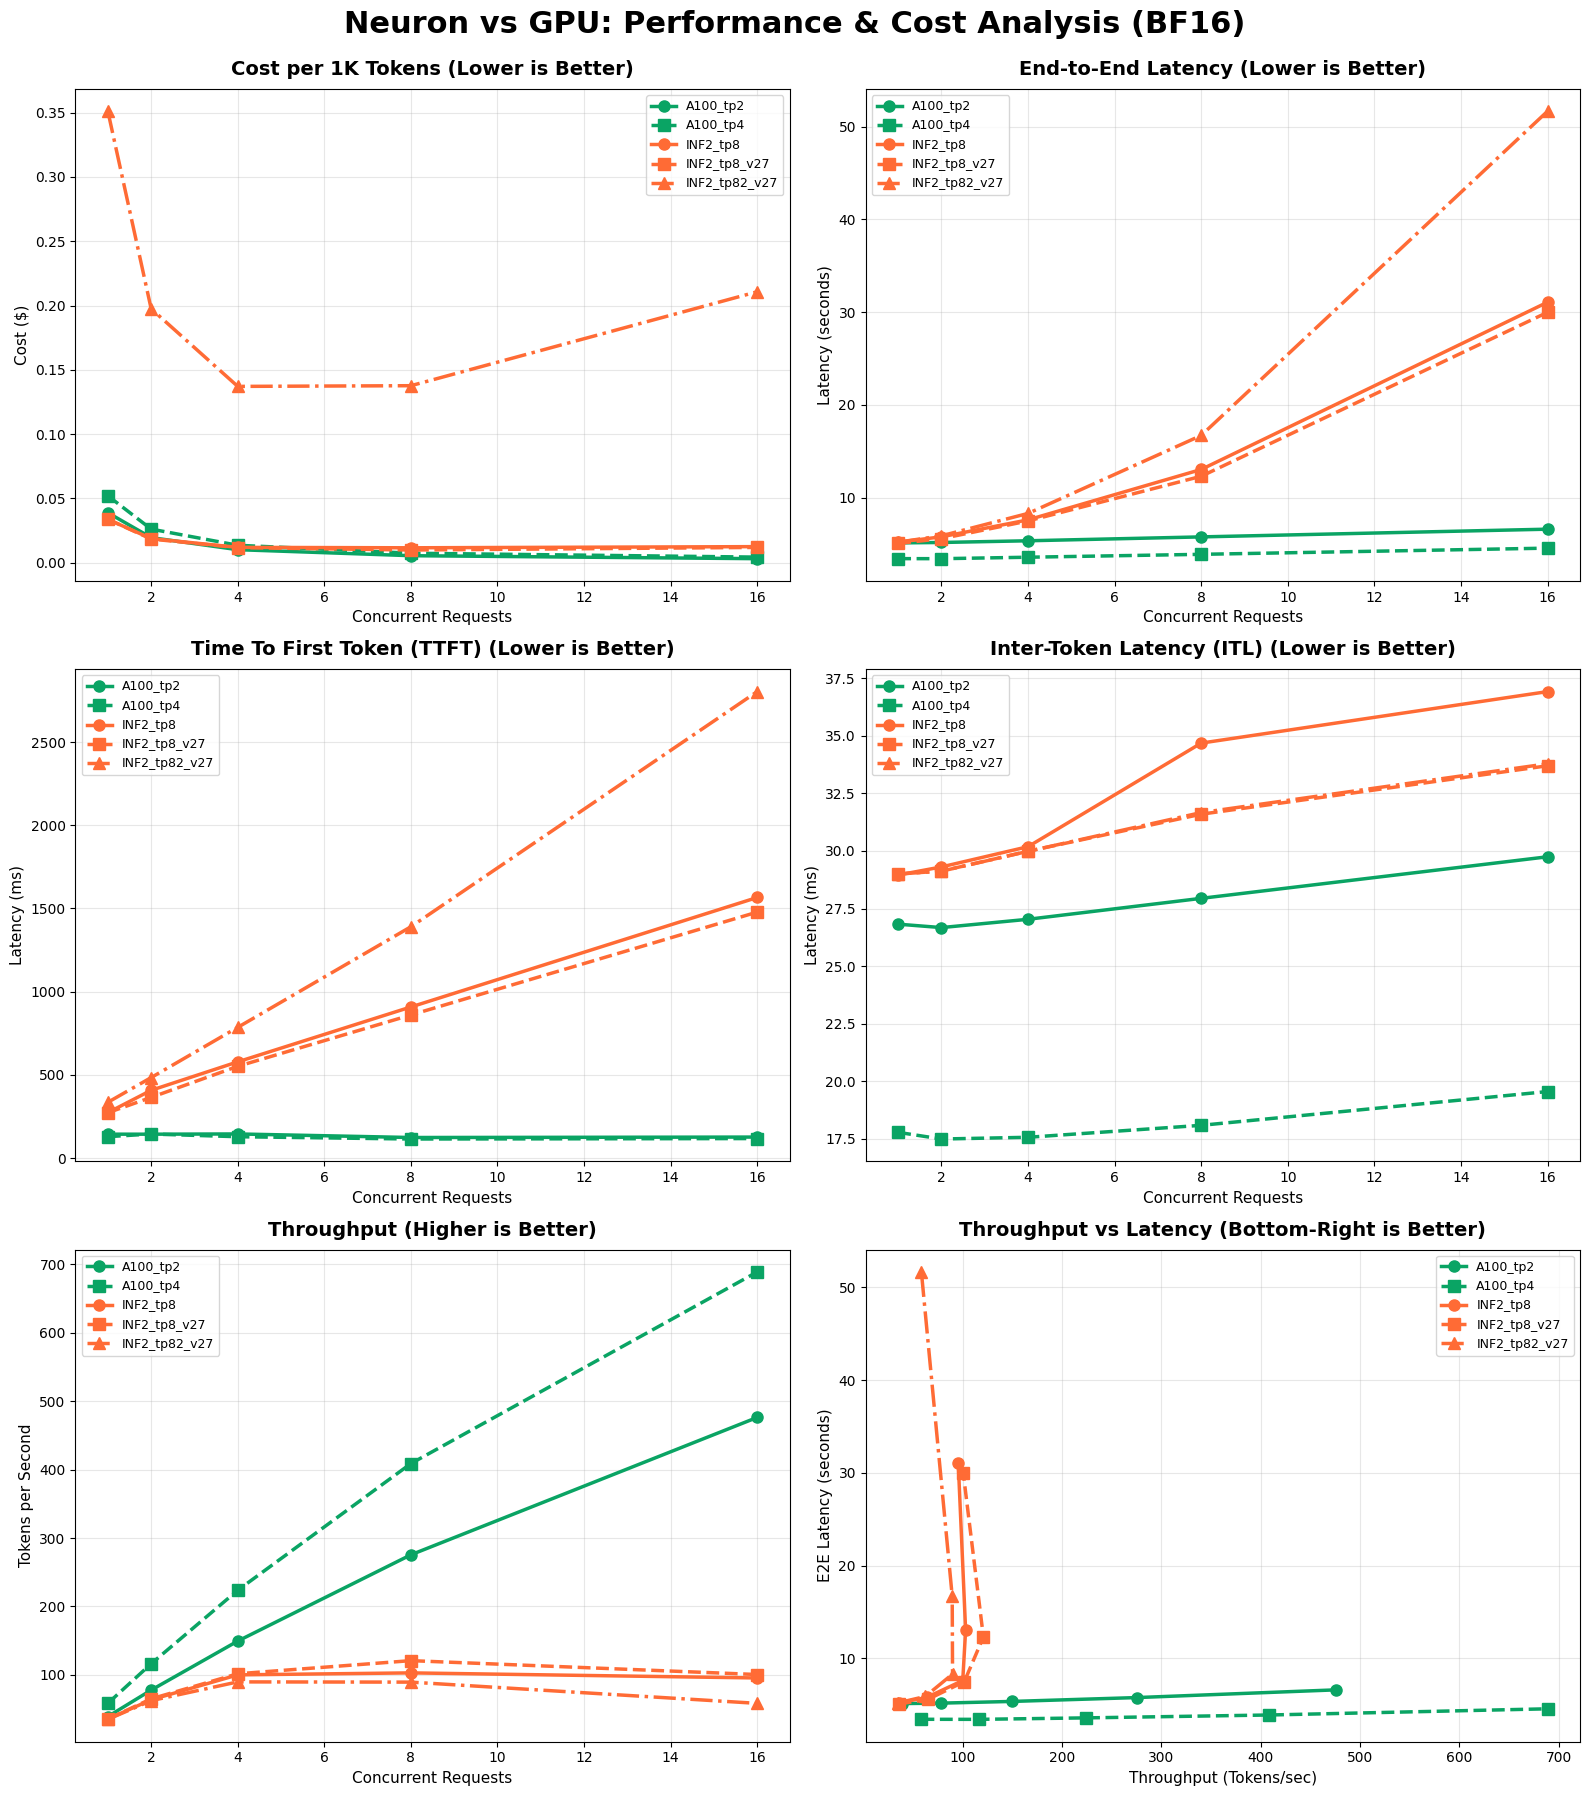

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# Read single CSV file with both GPU and Neuron data
df = combined_df.copy()

# Map CSV columns to plot variables
df['e2e_latency'] = df['median_e2el_ms'] / 1000
df['ttft'] = df['median_ttft_ms']
df['itl'] = df['median_itl_ms']
df['throughput'] = df['total_token_throughput']

# Sort by max_concurrency within each identifier group
df = df.sort_values(['identifier', 'max_concurrency'])

# Separate A100, Inf2, and TRN2 data
df_a100 = df[df['instance_type'] == 'A100'].copy()
df_inf2 = df[df['instance_type'] == 'INF2'].copy()
df_trn2 = df[df['instance_type'] == 'TRN2'].copy()

# Get unique identifiers for each type and sort by tp_degree
a100_identifiers = df_a100.drop_duplicates('identifier').sort_values('tp_degree')['identifier'].values
inf2_identifiers = df_inf2.drop_duplicates('identifier').sort_values('tp_degree')['identifier'].values
trn2_identifiers = df_trn2.drop_duplicates('identifier').sort_values('tp_degree')['identifier'].values

# Base colors
color_a100 = "#0AA464"
color_inf2 = "#FF6B35"
color_trn2 = "#6B5BFF"  # Purple/blue for TRN2

# Line styles and markers for variation
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X']

# Create 3x2 grid (6 spots, 5 used)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
if draw_quantize_plot:
    fig.suptitle('BF16 vs FP8: Impact of Quantization',
                 fontsize=22, fontweight='bold', y=0.995)
else:
    fig.suptitle('Neuron vs GPU: Performance & Cost Analysis (BF16)', 
                 fontsize=22, fontweight='bold', y=0.995)

# Plot 1: Cost per 1K Tokens (top-left)
ax1 = axes[0, 0]
for i, identifier in enumerate(a100_identifiers):
    data = df_a100[df_a100['identifier'] == identifier]
    ax1.plot(data['max_concurrency'], data['cost'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_a100, label=f'{identifier}')
for i, identifier in enumerate(inf2_identifiers):
    data = df_inf2[df_inf2['identifier'] == identifier]
    ax1.plot(data['max_concurrency'], data['cost'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_inf2, label=f'{identifier}')
for i, identifier in enumerate(trn2_identifiers):
    data = df_trn2[df_trn2['identifier'] == identifier]
    ax1.plot(data['max_concurrency'], data['cost'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_trn2, label=f'{identifier}')
ax1.set_title('Cost per 1K Tokens (Lower is Better)', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Concurrent Requests', fontsize=11)
ax1.set_ylabel('Cost ($)', fontsize=11)
ax1.legend(fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('white')

# Plot 2: E2E Latency (top-right)
ax2 = axes[0, 1]
for i, identifier in enumerate(a100_identifiers):
    data = df_a100[df_a100['identifier'] == identifier]
    ax2.plot(data['max_concurrency'], data['e2e_latency'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_a100, label=f'{identifier}')
for i, identifier in enumerate(inf2_identifiers):
    data = df_inf2[df_inf2['identifier'] == identifier]
    ax2.plot(data['max_concurrency'], data['e2e_latency'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_inf2, label=f'{identifier}')
for i, identifier in enumerate(trn2_identifiers):
    data = df_trn2[df_trn2['identifier'] == identifier]
    ax2.plot(data['max_concurrency'], data['e2e_latency'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_trn2, label=f'{identifier}')
ax2.set_title('End-to-End Latency (Lower is Better)', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Concurrent Requests', fontsize=11)
ax2.set_ylabel('Latency (seconds)', fontsize=11)
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('white')

# Plot 3: TTFT (middle-left)
ax3 = axes[1, 0]
for i, identifier in enumerate(a100_identifiers):
    data = df_a100[df_a100['identifier'] == identifier]
    ax3.plot(data['max_concurrency'], data['ttft'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_a100, label=f'{identifier}')
for i, identifier in enumerate(inf2_identifiers):
    data = df_inf2[df_inf2['identifier'] == identifier]
    ax3.plot(data['max_concurrency'], data['ttft'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_inf2, label=f'{identifier}')
for i, identifier in enumerate(trn2_identifiers):
    data = df_trn2[df_trn2['identifier'] == identifier]
    ax3.plot(data['max_concurrency'], data['ttft'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_trn2, label=f'{identifier}')
ax3.set_title('Time To First Token (TTFT) (Lower is Better)', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Concurrent Requests', fontsize=11)
ax3.set_ylabel('Latency (ms)', fontsize=11)
ax3.legend(fontsize=9, loc='best')
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('white')

# Plot 4: ITL (middle-right)
ax4 = axes[1, 1]
for i, identifier in enumerate(a100_identifiers):
    data = df_a100[df_a100['identifier'] == identifier]
    ax4.plot(data['max_concurrency'], data['itl'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_a100, label=f'{identifier}')
for i, identifier in enumerate(inf2_identifiers):
    data = df_inf2[df_inf2['identifier'] == identifier]
    ax4.plot(data['max_concurrency'], data['itl'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_inf2, label=f'{identifier}')
for i, identifier in enumerate(trn2_identifiers):
    data = df_trn2[df_trn2['identifier'] == identifier]
    ax4.plot(data['max_concurrency'], data['itl'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_trn2, label=f'{identifier}')
ax4.set_title('Inter-Token Latency (ITL) (Lower is Better)', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Concurrent Requests', fontsize=11)
ax4.set_ylabel('Latency (ms)', fontsize=11)
ax4.legend(fontsize=9, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_facecolor('white')

# Plot 5: Throughput (bottom-left)
ax5 = axes[2, 0]
for i, identifier in enumerate(a100_identifiers):
    data = df_a100[df_a100['identifier'] == identifier]
    ax5.plot(data['max_concurrency'], data['throughput'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_a100, label=f'{identifier}')
for i, identifier in enumerate(inf2_identifiers):
    data = df_inf2[df_inf2['identifier'] == identifier]
    ax5.plot(data['max_concurrency'], data['throughput'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_inf2, label=f'{identifier}')
for i, identifier in enumerate(trn2_identifiers):
    data = df_trn2[df_trn2['identifier'] == identifier]
    ax5.plot(data['max_concurrency'], data['throughput'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_trn2, label=f'{identifier}')
ax5.set_title('Throughput (Higher is Better)', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('Concurrent Requests', fontsize=11)
ax5.set_ylabel('Tokens per Second', fontsize=11)
ax5.legend(fontsize=9, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_facecolor('white')

# Plot 6: Throughput vs E2E Latency (bottom-right)
ax6 = axes[2, 1]
for i, identifier in enumerate(a100_identifiers):
    data = df_a100[df_a100['identifier'] == identifier]
    ax6.plot(data['throughput'], data['e2e_latency'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_a100, label=f'{identifier}')
for i, identifier in enumerate(inf2_identifiers):
    data = df_inf2[df_inf2['identifier'] == identifier]
    ax6.plot(data['throughput'], data['e2e_latency'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_inf2, label=f'{identifier}')
for i, identifier in enumerate(trn2_identifiers):
    data = df_trn2[df_trn2['identifier'] == identifier]
    ax6.plot(data['throughput'], data['e2e_latency'], 
             marker=markers[i % len(markers)], 
             linestyle=line_styles[i % len(line_styles)],
             linewidth=2.5, markersize=8, 
             color=color_trn2, label=f'{identifier}')
ax6.set_title('Throughput vs Latency (Bottom-Right is Better)', fontsize=14, fontweight='bold', pad=10)
ax6.set_xlabel('Throughput (Tokens/sec)', fontsize=11)
ax6.set_ylabel('E2E Latency (seconds)', fontsize=11)
ax6.legend(fontsize=9, loc='best')
ax6.grid(True, alpha=0.3)
ax6.set_facecolor('white')

plt.tight_layout()
plt.savefig('performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import os
import pandas as pd

results = os.listdir("/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/path_to_optimization")

version_dict = {
    "v3": "Base",
    "v4": "+ FlashAttention (CTX)",
    "v5": "+ FlashAttention (TKG)",
    "v6": "+ Fused QKV",
    "v7": "+ On Device Sampling",
    "v8": "+ SigLIP Refactoring",
    "v9": "+ FA for SigLIP Attention",
    "v10": "+ Fused QKV for SigLIP Attention",
    "v18": "+ Async Mode"
}

dfs = []
for f in results:
    if f.startswith("gemma-3-27b-it"):
        target_file = f"/home/ubuntu/daanggn-neuron-inference-migration/latency_benchmark/results/path_to_optimization/{f}"
        df = pd.read_json(target_file)
        version_number = f.split("_")[0].split("-")[-1]
        df['identifier'] = version_number
        df['configuration'] = version_dict[version_number]
        df = df[[
            'identifier', 'configuration', 'completed', 'failed',
            'request_throughput', 'total_token_throughput', 
            'mean_ttft_ms', 'median_ttft_ms', 'p99_ttft_ms', 
            'mean_tpot_ms', 'median_tpot_ms', 'p99_tpot_ms', 
            'mean_itl_ms', 'median_itl_ms', 'p99_itl_ms', 
            'mean_e2el_ms', 'median_e2el_ms', 'p99_e2el_ms'
        ]].drop_duplicates()
        dfs.append(df)
    
dfs = pd.concat(dfs)
dfs = dfs.sort_values(by='identifier', key=lambda x: x.str.extract('(\d+)', expand=False).astype(int))
dfs = dfs.reset_index(drop=True)
dfs

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import FancyArrowPatch

# Read data from CSV file
# csv_file = 'performance_data.csv'  # Change this to your CSV file path
# df = pd.read_csv(csv_file)

df = dfs.copy()
# Map CSV columns to plotting variables
df = df.rename(columns={
    'median_ttft_ms': 'TTFT_p50',
    'p99_ttft_ms': 'TTFT_p99',
    'median_tpot_ms': 'TPOT_p50',
    'p99_tpot_ms': 'TPOT_p99',
    'median_itl_ms': 'ITL_p50',
    'p99_itl_ms': 'ITL_p99',
    'request_throughput': 'Req/sec',
    'total_token_throughput': 'Tokens/sec'
})

# Create step labels
step_labels = [f"Step {i}\n{config}" for i, config in enumerate(df['configuration'], 1)]

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Incremental Neuron SDK Optimizations - Performance Impact', 
             fontsize=16, fontweight='bold', y=0.995)

# Color palette - use gradient to show progression
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))

# 1. TTFT (Time To First Token)
ax1 = axes[0, 0]
x = np.arange(len(df))
bars1 = ax1.bar(x, df['TTFT_p50'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.errorbar(x, df['TTFT_p50'], 
             yerr=[df['TTFT_p50'] - df['TTFT_p50'], df['TTFT_p99'] - df['TTFT_p50']], 
             fmt='none', ecolor='black', capsize=3, alpha=0.6)
ax1.set_ylabel('TTFT (ms)', fontsize=11, fontweight='bold')
ax1.set_title('Time To First Token (Lower is Better)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(step_labels, fontsize=10, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=df['TTFT_p50'].min(), color='green', linestyle='--', 
            alpha=0.5, label=f'Best: {df["TTFT_p50"].min():.1f}ms')
ax1.legend(fontsize=9)
# Adjust y-axis to show differences better
ttft_min = df['TTFT_p50'].min()
ttft_max = df['TTFT_p99'].max()
ttft_range = ttft_max - ttft_min
ax1.set_ylim(ttft_min - 0.15 * ttft_range, ttft_max + 0.1 * ttft_range)

# Add arrows between bars
for i in range(len(df) - 1):
    arrow = FancyArrowPatch((x[i] + 0.35, df['TTFT_p50'].iloc[i]), 
                           (x[i+1] - 0.35, df['TTFT_p50'].iloc[i+1]),
                           arrowstyle='->', mutation_scale=15, linewidth=1.5,
                           color='darkblue', alpha=0.4, zorder=10)
    ax1.add_patch(arrow)

# 2. ITL (Inter-Token Latency)
ax2 = axes[0, 1]
itl_colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(df)))
bars2 = ax2.bar(x, df['ITL_p50'], color=itl_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.errorbar(x, df['ITL_p50'], 
             yerr=[df['ITL_p50'] - df['ITL_p50'], df['ITL_p99'] - df['ITL_p50']], 
             fmt='none', ecolor='black', capsize=3, alpha=0.6)
ax2.set_ylabel('ITL (ms)', fontsize=11, fontweight='bold')
ax2.set_title('Inter-Token Latency (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(step_labels, fontsize=10, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=df['ITL_p50'].min(), color='green', linestyle='--', 
            alpha=0.5, label=f'Best: {df["ITL_p50"].min():.2f}ms')
ax2.legend(fontsize=9)
# Adjust y-axis to show differences better
itl_min = df['ITL_p50'].min()
itl_max = df['ITL_p99'].max()
itl_range = itl_max - itl_min
ax2.set_ylim(itl_min - 0.15 * itl_range, itl_max + 0.1 * itl_range)

# Add arrows between bars
for i in range(len(df) - 1):
    arrow = FancyArrowPatch((x[i] + 0.35, df['ITL_p50'].iloc[i]), 
                           (x[i+1] - 0.35, df['ITL_p50'].iloc[i+1]),
                           arrowstyle='->', mutation_scale=15, linewidth=1.5,
                           color='darkblue', alpha=0.4, zorder=10)
    ax2.add_patch(arrow)

# 3. Throughput
ax3 = axes[1, 0]
throughput_colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(df)))
bars3 = ax3.bar(x, df['Tokens/sec'], color=throughput_colors, alpha=0.8, 
        edgecolor='black', linewidth=0.5)
ax3.set_ylabel('Throughput (tokens/sec)', fontsize=11, fontweight='bold')
ax3.set_title('Throughput (Higher is Better)', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(step_labels, fontsize=10, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.axhline(y=df['Tokens/sec'].max(), color='green', linestyle='--', 
            alpha=0.5, label=f'Best: {df["Tokens/sec"].max():.1f} tok/s')
ax3.legend(fontsize=9)
# Adjust y-axis to show differences better
tput_min = df['Tokens/sec'].min()
tput_max = df['Tokens/sec'].max()
tput_range = tput_max - tput_min
ax3.set_ylim(tput_min - 0.15 * tput_range, tput_max + 0.1 * tput_range)

# Add arrows between bars
for i in range(len(df) - 1):
    arrow = FancyArrowPatch((x[i] + 0.35, df['Tokens/sec'].iloc[i]), 
                           (x[i+1] - 0.35, df['Tokens/sec'].iloc[i+1]),
                           arrowstyle='->', mutation_scale=15, linewidth=1.5,
                           color='darkgreen', alpha=0.4, zorder=10)
    ax3.add_patch(arrow)

# 4. Combined improvement view (normalized)
ax4 = axes[1, 1]
# Normalize metrics (lower is better for latency, higher for throughput)
ttft_norm = (df['TTFT_p50'].max() - df['TTFT_p50']) / (df['TTFT_p50'].max() - df['TTFT_p50'].min()) * 100
itl_norm = (df['ITL_p50'].max() - df['ITL_p50']) / (df['ITL_p50'].max() - df['ITL_p50'].min()) * 100
throughput_norm = (df['Tokens/sec'] - df['Tokens/sec'].min()) / (df['Tokens/sec'].max() - df['Tokens/sec'].min()) * 100

ax4.plot(x, ttft_norm, marker='o', linewidth=2.5, markersize=10, label='TTFT Improvement', color='#1f77b4')
ax4.plot(x, itl_norm, marker='s', linewidth=2.5, markersize=10, label='ITL Improvement', color='#ff7f0e')
ax4.plot(x, throughput_norm, marker='^', linewidth=2.5, markersize=10, label='Throughput Improvement', color='#2ca02c')

ax4.set_ylabel('Improvement (%)', fontsize=11, fontweight='bold')
ax4.set_title('Cumulative Performance Improvement', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(step_labels, fontsize=10, rotation=45, ha='right')
ax4.grid(alpha=0.3, linestyle='--')
ax4.legend(fontsize=9, loc='best')
ax4.set_ylim(-10, 110)

plt.tight_layout()
plt.savefig('neuron_sdk_performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n=== Performance Summary ===")
print(f"Best TTFT: {df['TTFT_p50'].min():.2f}ms (Step {df['TTFT_p50'].idxmin() + 1})")
print(f"Best ITL: {df['ITL_p50'].min():.2f}ms (Step {df['ITL_p50'].idxmin() + 1})")
print(f"Best Throughput: {df['Tokens/sec'].max():.2f} tok/s (Step {df['Tokens/sec'].idxmax() + 1})")
print(f"\nTotal TTFT improvement: {((df['TTFT_p50'].iloc[0] - df['TTFT_p50'].iloc[-1]) / df['TTFT_p50'].iloc[0] * 100):.1f}%")
print(f"Total ITL improvement: {((df['ITL_p50'].iloc[0] - df['ITL_p50'].iloc[-1]) / df['ITL_p50'].iloc[0] * 100):.1f}%")
print(f"Total Throughput improvement: {((df['Tokens/sec'].iloc[-1] - df['Tokens/sec'].iloc[0]) / df['Tokens/sec'].iloc[0] * 100):.1f}%")